<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/09_exgaussian_distributional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 9 — Ex-Gaussian distributional model

Notebooks 6–8 represented the right skew of reaction times with a lognormal likelihood, which models log reaction time. Their mean structure therefore acted multiplicatively, and Notebook 8 gave each participant their own residual scale on that log scale.

This notebook represents right skew differently. An **ex-Gaussian** likelihood adds an exponential tail to a Gaussian distribution, so the skew comes from the shape of the likelihood rather than from a log transform. The mean structure returns to Notebook 5's, in milliseconds, and each participant keeps their own residual scale, built as in Notebook 8. The new pieces are the likelihood and its tail, whose priors are chosen in milliseconds and then translated to the log scale.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

participants = sorted(sleep["Subject"].unique(), key=int)
participant_to_idx = {participant: i for i, participant in enumerate(participants)}
participant_idx = sleep["Subject"].map(participant_to_idx).to_numpy()

assert participant_idx.min() == 0
assert participant_idx.max() == len(participants) - 1
assert np.array_equal(
    np.asarray(participants)[participant_idx],
    sleep["Subject"].to_numpy(),
)

print(f"{len(participants)} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helper

The participant plotting helper from the previous notebooks is supplied. It can optionally restrict plots to selected participants using the standard ArviZ `coords` argument. Panels appear in participant order (308, 309, …, 372), left to right and top to bottom.

In [4]:
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}

PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(
        sleep[["Subject", "Days"]],
        names=["participant", "day"],
    ),
    "obs_id",
)

def plot_participants(dt, group, var, coords=None):
    """One panel per participant, optionally restricted with ArviZ coords."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="y",
        group=group,
        plot_dim="day",
        coords=coords,
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")
    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")
    return pc

## 1. Build the ex-Gaussian model

### 1.1 The model

$$
y_i \sim \operatorname{ExGaussian}(\mu_{y,i}, sd_{y,s[i]}, \nu)
$$

$$
\mu_{y,i}
=
b_{0,s[i]}
+
b_{1,s[i]}\,\mathrm{days}_i
$$

$$
b_{0,s}
\sim
\operatorname{Normal}(\mu_{b0}, sd_{b0})
$$

$$
b_{1,s}
\sim
\operatorname{Normal}(\mu_{b1}, sd_{b1})
$$

$$
\log sd_{y,s}
\sim
\operatorname{Normal}(\mu_{\log sd_y}, sd_{\log sd_y}).
$$

Here $s[i]$ identifies the participant who produced observation $i$. The second, third, and fourth lines are Notebook 5's mean structure, in milliseconds, and the last line is Notebook 8's residual-scale hierarchy.

The first line is new. An ex-Gaussian reaction time is the sum of two independent parts,

$$
y_i = g_i + e_i,
$$

where the Gaussian part $g_i \sim \operatorname{Normal}(\mu_{y,i}, sd_{y,s[i]})$ scatters symmetrically around $\mu_{y,i}$, and the exponential part $e_i \sim \operatorname{Exponential}(\mathrm{scale}=\nu)$ is never negative and has mean $\nu$. PyMC's `pm.ExGaussian(mu, sigma, nu)` uses exactly this parameterization. The tail mean $\nu$ has no participant subscript: all participants share one tail.

### 1.2 Compare ex-Gaussian distributions with different tails.

The supplied code draws three ex-Gaussian distributions with the same Gaussian part, $\mu = 250$ ms and $sd = 30$ ms, and different tail means $\nu$. The dashed lines mark each distribution's mean.

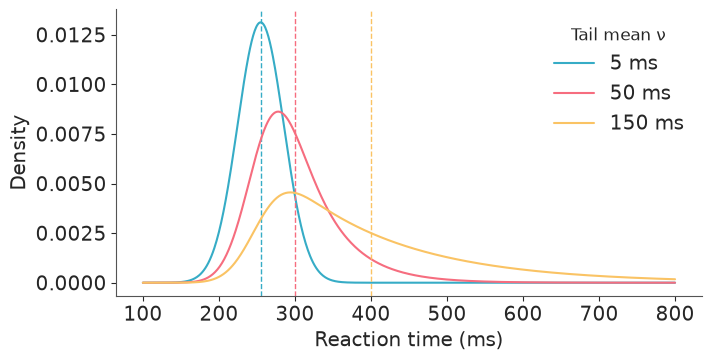

In [5]:
rt = np.linspace(100, 800, 701)

fig, ax = plt.subplots(figsize=(7, 3.5))
for nu_value in [5.0, 50.0, 150.0]:
    # Floats, not integers: PyTensor stores 30 as an 8-bit integer, so 30**2 would overflow.
    exgaussian = pm.ExGaussian.dist(mu=250.0, sigma=30.0, nu=nu_value)
    density = np.exp(pm.logp(exgaussian, rt).eval())
    (line,) = ax.plot(rt, density, label=f"{nu_value:.0f} ms")
    ax.axvline(250.0 + nu_value, color=line.get_color(), linestyle="--", linewidth=1)

ax.set_xlabel("Reaction time (ms)")
ax.set_ylabel("Density")
ax.legend(title="Tail mean ν")
plt.show()

### 1.3 What does $\nu$ represent?

How does the distribution change as $\nu$ grows?

$\nu$ is the mean of the exponential part: the average amount by which a reaction time exceeds its Gaussian part. With $\nu = 5$ ms the distribution is almost the Gaussian itself. As $\nu$ grows, the right tail lengthens and the distribution becomes more spread out and more right-skewed, while its left side keeps the steep rise of the Gaussian part: slow reaction times become more common, fast ones do not.

### 1.4 Why is the expected reaction time $\mu_{y,i} + \nu$ rather than $\mu_{y,i}$?

Use the two parts of $y_i$ from Question 1.1, and check your answer against the dashed lines in Question 1.2.

The expectation of a sum is the sum of the expectations: $\mathrm{E}[g_i] = \mu_{y,i}$ and $\mathrm{E}[e_i] = \nu$, so $\mathrm{E}[y_i] = \mu_{y,i} + \nu$. $\mu_{y,i}$ is the center of the Gaussian part only; every reaction time also has a nonnegative exponential part added to it.

In Question 1.2 the dashed means sit at 255, 300, and 400 ms, exactly $\nu$ above $\mu = 250$ ms, while the peaks move much less, to about 255, 280, and 295 ms.

### 1.5 Can the ex-Gaussian produce a negative reaction time?

Compare with the lognormal likelihood of Notebooks 6–8.

Yes. The exponential part is never negative, but the Gaussian part is unbounded below, so reaction times far below $\mu_{y,i}$, including negative ones, keep a small probability. The lognormal likelihood of Notebooks 6–8 made negative reaction times impossible; the ex-Gaussian, like the Gaussian likelihood of Notebooks 1–5, only makes them improbable, as long as $\mu_{y,i}$ lies many Gaussian standard deviations above zero.

### 1.6 Why does $\mu_{y,i}$ need no log link here, unlike in Notebooks 6–8?

In Notebooks 6–8, $b_0$ and $b_1$ were on the log scale. What scale are they on now, and which parameters of this model do need a log link?

The lognormal's location is the mean of **log** reaction time, so in Notebooks 6–8 the whole mean structure had to live on the log scale, and its effects were proportional. The ex-Gaussian's $\mu$ is an ordinary location in milliseconds that can take any real value, so $\mu_{y,i} = b_{0,s[i]} + b_{1,s[i]}\,\mathrm{days}_i$ needs no transformation: `b0` is in milliseconds and `b1` in milliseconds per day, as in Notebook 5. The skew now comes from the exponential tail, not from a log transform.

Only the two parameters that must be positive need a log link: the Gaussian standard deviation `sd_y`, as in Notebook 8, and the tail mean `nu`.

### 1.7 The supplied mean structure

The data, coordinates, and mean structure are Notebook 5's, with the same prior constants, and are supplied. As in Notebook 8, the model is created without the remaining nodes, which are added in separate `with model:` blocks.

In [6]:
coords = {
    "obs_id": np.arange(len(sleep)),
    "participant": participants,
}

# Hyperprior constants for the intercept hierarchy (ms), from Notebook 5
mu_mu_b0 = 250
sd_mu_b0 = 100
sd_sd_b0 = 25

# Hyperprior constants for the slope hierarchy (ms/day), from Notebook 5
mu_mu_b1 = 0
sd_mu_b1 = 20
sd_sd_b1 = 10

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
    pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

    # Varying intercepts
    mu_b0 = pm.Normal("mu_b0", mu=mu_mu_b0, sigma=sd_mu_b0)
    sd_b0 = pm.Exponential("sd_b0", scale=sd_sd_b0)
    b0 = pm.Normal("b0", mu=mu_b0, sigma=sd_b0, dims="participant")

    # Varying slopes
    mu_b1 = pm.Normal("mu_b1", mu=mu_mu_b1, sigma=sd_mu_b1)
    sd_b1 = pm.Exponential("sd_b1", scale=sd_sd_b1)
    b1 = pm.Normal("b1", mu=mu_b1, sigma=sd_b1, dims="participant")

    # Location of the Gaussian part (ms)
    mu_y = pm.Deterministic(
        "mu_y",
        b0[pidx] + b1[pidx] * days,
        dims="obs_id",
    )

### 1.8 What do `b0` and `b1` describe in this model?

They keep Notebook 5's priors, which were chosen for the baseline reaction time and its daily change. Is `mu_b0` still the typical baseline reaction time, and is `b1` still the daily change in expected reaction time?

`b1` is, but `b0` is not. Because $\nu$ does not change with days, a participant's expected reaction time is $b_{0,s} + \nu + b_{1,s}\,\mathrm{days}$, so `b1` is still the daily change in expected reaction time, in ms/day, directly comparable with Notebook 5. `b0`, however, is now the baseline location of the Gaussian part, which lies $\nu$ below the baseline expected reaction time, and `mu_b0` is the typical value of that location.

Notebook 5's prior for `mu_b0`, $\operatorname{Normal}(250, 100)$, is broad enough that a shift of a few tens of milliseconds hardly matters, so it is kept unchanged.

### 1.9 The supplied residual-scale hierarchy

The standard deviation of the Gaussian part gets Notebook 8's participant-level hierarchy, with the same names, and is supplied. Its prior is chosen in milliseconds: we expect a typical participant's Gaussian standard deviation to be around 30 ms, with about 95% prior probability between 11 and 80 ms. On the log scale, $\log 30 \approx 3.4$ and the limits are about $3.4 \pm 2(0.5)$, so

$$
\mu_{\log sd_y} \sim \operatorname{Normal}(\log 30, 0.5).
$$

The prior for between-participant differences is Notebook 8's, $sd_{\log sd_y} \sim \operatorname{Exponential}(\mathrm{scale}=1/3)$.

In [7]:
# Hyperprior constants for the residual-scale hierarchy (log of the Gaussian SD in ms)
mu_mu_log_sd_y = np.log(30)
sd_mu_log_sd_y = 0.5
sd_sd_log_sd_y = 1 / 3

with model:
    mu_log_sd_y = pm.Normal("mu_log_sd_y", mu=mu_mu_log_sd_y, sigma=sd_mu_log_sd_y)
    sd_log_sd_y = pm.Exponential("sd_log_sd_y", scale=sd_sd_log_sd_y)
    log_sd_y = pm.Normal(
        "log_sd_y",
        mu=mu_log_sd_y,
        sigma=sd_log_sd_y,
        dims="participant",
    )
    sd_y = pm.Deterministic("sd_y", pm.math.exp(log_sd_y), dims="participant")

### 1.10 How does this hierarchy differ from Notebook 8's?

The names and structure are Notebook 8's. What does `sd_y` measure here? Why is the prior center for `mu_log_sd_y` about 3.4 here but −2.5 in Notebook 8, while the prior for `sd_log_sd_y` is unchanged?

Here `sd_y` is the standard deviation of the Gaussian part of a participant's reaction times, in milliseconds: scatter of a given number of milliseconds around the trajectory, the same on a slow day as on a fast one. In Notebook 8, `sd_y` was the standard deviation of **log** reaction time, a proportion of about 0.08, whose log is about −2.5; a standard deviation of about 30 ms has a log of about 3.4.

The log link does the same job in both notebooks: it keeps `sd_y` positive and makes differences between participants proportional. That is why the prior for `sd_log_sd_y` carries over unchanged: participants' scales differing by a factor of $e^{sd_{\log sd_y}}$ per standard deviation means the same thing whatever the units of `sd_y`.

### 1.11 Why does $\nu$ have no participant subscript?

Each participant has their own Gaussian standard deviation, but all share one tail. Why is that a reasonable choice for these data, and what would change if $\nu$ also varied by participant?

Telling a tail apart from Gaussian scatter requires the shape of the distribution: whether large deviations fall mostly above the trajectory rather than evenly on both sides. Eight observations per participant, which must also determine that participant's intercept, slope, and Gaussian standard deviation, cannot show that shape; the shared tail is estimated from the asymmetry of all 144 observations together. Sharing it is a modeling choice: participants may differ in how variable they are, but are assumed to have the same tail.

If $\nu$ varied by participant, the model would need a fourth hierarchy, for $\log \nu_s$. Each participant's own observations would say almost nothing about their tail, so the participants' tails would mostly repeat the population distribution, while competing with each participant's intercept and Gaussian standard deviation to explain the same few observations. The model would be larger and harder to sample, and would gain very little.

### 1.12 What prior should we use for the tail mean?

Suppose we expect the tail mean $\nu$ to be around 50 ms and regard values between about 11 and 220 ms as plausible. Like `sd_y`, $\nu$ must be positive, so we give it a log link: a Normal prior for $\log \nu$. What Normal distribution puts about 95% of its probability between those limits?

The center is $\log 50 \approx 3.9$. The limits are $\log 11 \approx 2.4$ and $\log 220 \approx 5.4$, so the range is $3.9 \pm 2(0.75)$ on the log scale:

$$
\log \nu \sim \operatorname{Normal}(\log 50, 0.75).
$$

In milliseconds the range is lopsided, about 40 ms below the center and 170 ms above it, but on the log scale it is symmetric: a factor of about 4.5 either way.

### 1.13 Add the tail to the model.

Store the constants from Question 1.12 in `mu_log_nu` and `sd_log_nu`, writing the center as `np.log(50)` so that the value chosen in milliseconds stays visible. Then, in a `with model:` block, add `log_nu` and the tail mean itself as a `pm.Deterministic` named `nu`.

In [8]:
# Prior constants for the tail (log of the tail mean in ms)
mu_log_nu = np.log(50)
sd_log_nu = 0.75

with model:
    log_nu = pm.Normal("log_nu", mu=mu_log_nu, sigma=sd_log_nu)
    nu = pm.Deterministic("nu", pm.math.exp(log_nu))

### 1.14 Complete the model.

Add the expected reaction time in milliseconds (Question 1.4) as a `pm.Deterministic` named `mean_rt`, and the ex-Gaussian likelihood `y` for the observed reaction times. Each observation uses its participant's Gaussian standard deviation and the shared tail.

In [9]:
with model:
    # Expected reaction time in milliseconds
    mean_rt = pm.Deterministic("mean_rt", mu_y + nu, dims="obs_id")

    y = pm.ExGaussian(
        "y",
        mu=mu_y,
        sigma=sd_y[pidx],
        nu=nu,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

### 1.15 Inspect the completed model.

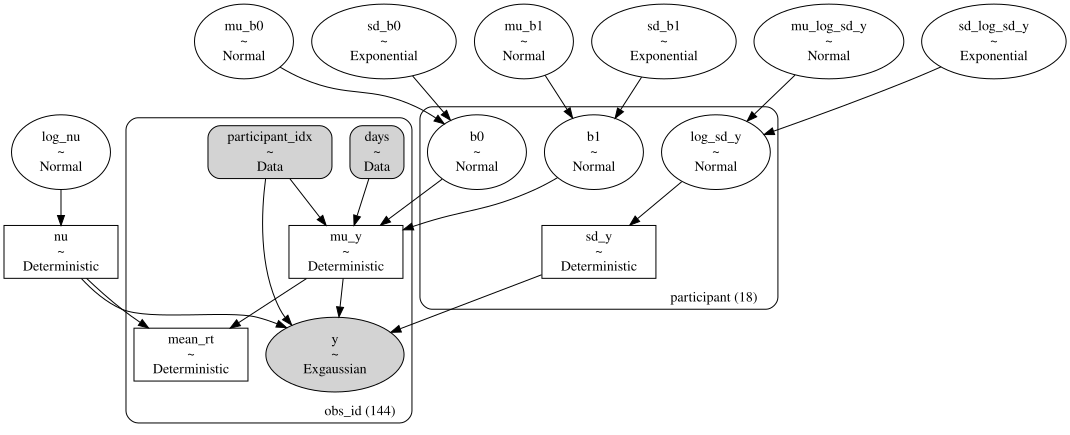

In [10]:
pm.model_to_graphviz(model)

### 1.16 Which nodes are shared by all participants, and where does the tail enter the model?

The participant plate holds `b0`, `b1`, `log_sd_y`, and `sd_y`. `log_nu` and `nu` sit outside every plate, like the population parameters: one tail for all 144 observations. `nu` enters the model in two places: the likelihood `y`, and `mean_rt`, which adds it to `mu_y`.

Unlike in Notebook 8, `sd_y` does not feed into `mean_rt`: the expected reaction time depends on the location of the Gaussian part and on the tail, but not on how widely the Gaussian part scatters.

## 2. Check the prior implications

### 2.1 Criteria

The prior predictions should meet the criteria established in Notebook 1: predicted reaction times should not routinely be physically impossible, reaction times near baseline should mostly occupy a broadly plausible range, and the model should allow substantial change across the seven days without routinely generating absurd trajectories. The mean-structure priors are Notebook 5's, whose prior predictive check found them broad, with 90% bands reaching below zero late in the week (Notebook 5, Question 2.5).

Two criteria concern the new likelihood. As in Notebook 8, the residual-scale hierarchy should allow participants to differ noticeably in day-to-day variability without making enormous differences routine. The tail prior should allow anything from an almost symmetric distribution to a clearly right-skewed one (Question 1.2), without making tails of several hundred milliseconds routine.

### 2.2 Draw from the prior.

In [11]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["mu_log_sd_y", "sd_log_sd_y", "nu", "y"],
        random_seed=RANDOM_SEED,
    )

Sampling: [b0, b1, log_nu, log_sd_y, mu_b0, mu_b1, mu_log_sd_y, sd_b0, sd_b1, sd_log_sd_y, y]


### 2.3 Plot the priors of the residual-scale hyperparameters and the tail mean.

Use `azp.plot_dist` for `mu_log_sd_y`, `sd_log_sd_y`, and `nu`, with 90% HDIs and the mean as the point estimate.

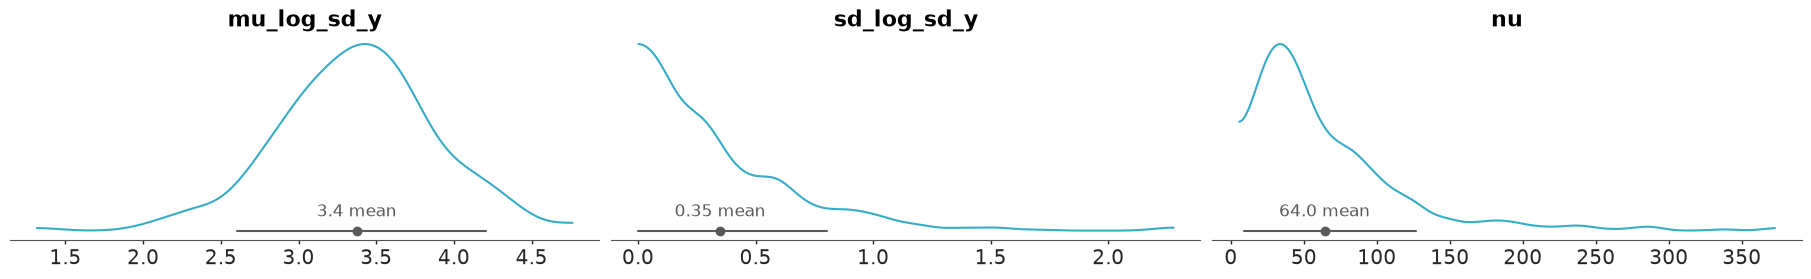

In [12]:
azp.plot_dist(
    prior,
    group="prior",
    var_names=["mu_log_sd_y", "sd_log_sd_y", "nu"],
    ci_prob=0.90,
    ci_kind="hdi",
    point_estimate="mean",
);

### 2.4 Are these priors reasonable?

Translate the 90% HDI for `mu_log_sd_y` into a typical Gaussian standard deviation in milliseconds, and read the tail mean `nu` directly in milliseconds. Why is the mean of the `nu` prior above 50 ms?

Yes. The 90% HDI for `mu_log_sd_y` runs from about 2.6 to 4.2, so a typical participant's Gaussian standard deviation lies between about $e^{2.6} \approx 13$ and $e^{4.2} \approx 67$ ms. `sd_log_sd_y` has Notebook 8's prior, mostly below about 0.8: at its mean, 1/3, participants' Gaussian standard deviations differ by a factor of about 1.4 per between-participant standard deviation, and much larger differences are possible but unusual.

The 90% HDI for `nu` runs from about 9 to 130 ms: from an almost symmetric distribution to a clearly right-skewed one, with tails of several hundred milliseconds rare. It sits lower than the 11–220 ms range of Question 1.12, partly because it is a 90% rather than a 95% interval, and partly because, for a right-skewed distribution, the narrowest interval shifts toward the dense region near the peak. The mean, about 64 ms, lies above 50 ms because 50 ms is the median: exponentiating the center of a log-scale distribution gives a median (Notebook 8, Question 1.5), and the long right tail pulls the mean above it.

### 2.5 Plot the prior predictive reaction times.

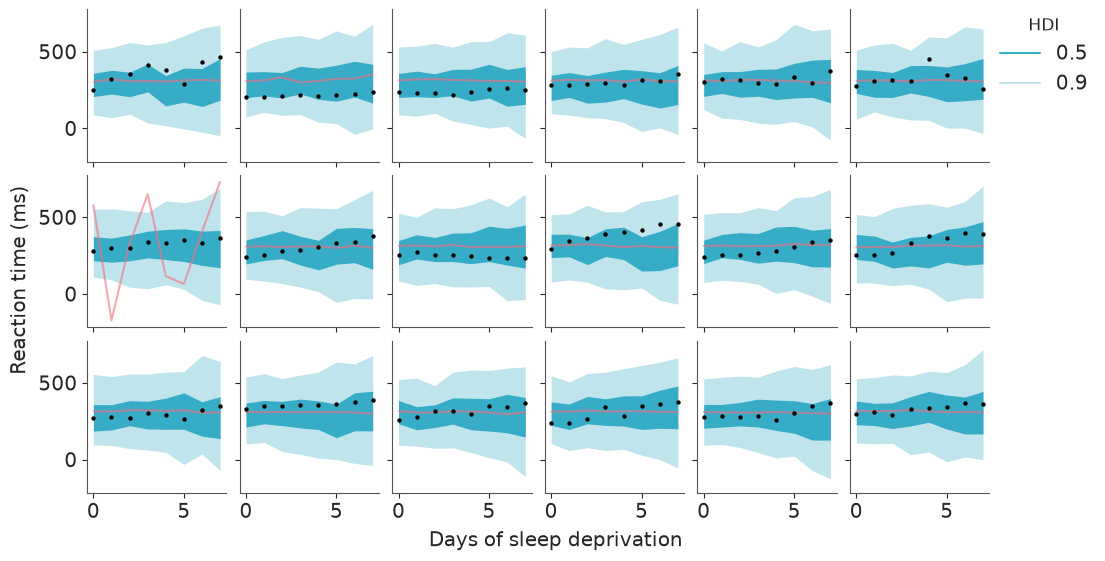

In [13]:
plot_participants(prior, "prior_predictive", "y")
plt.show()

### 2.6 Do these prior predictions meet the criteria established in Notebook 1?

Judge support, baseline scale, and changes across days, and compare with the prior predictive checks of Notebook 5 and of Notebooks 6–8.

Broadly, with the same warning as Notebook 5. At baseline the 50% bands span roughly 210–360 ms and the 90% bands roughly 95–530 ms, and almost every observed reaction time lies inside its panel's 50% band. The prior is centered on plausible reaction times, not on the implausibly fast ones of Notebooks 6–8, whose log-scale baseline prior was centered on a median of about 150 ms. Across the week the bands widen gradually, allowing substantial change without routinely absurd trajectories.

As in Notebook 5, however, the lower edges of the 90% bands reach zero or below late in the week: in every panel by day 7, and in a third of them already on day 5. These negative reaction times come mainly from the broad mean-structure priors: steep negative slopes, accumulated over a week, take the trajectory itself below zero, and a likelihood whose Gaussian part is unbounded below (Question 1.5) does not prevent it. They are not central predictions, and the new residual-scale and tail priors do not cause them, so we proceed while retaining this limitation.

### 2.7 Why does one panel's mean line zigzag?

In participant 333's panel (second row, first panel), the mean line swings from day to day, from about −170 ms to more than 700 ms, while every other panel's mean line stays near 300 ms. Which part of the model can move a single day's mean down as well as up, and which prior must be responsible?

Only the Gaussian part of the residual. A large intercept would shift the whole trajectory, and a large slope would build up steadily across the days. The exponential tail only ever adds positive values, so it cannot pull a day's mean down. A Gaussian residual can be negative or positive. To move a mean of 500 draws by several hundred milliseconds, one draw must contain residuals of the order of ±100–250 s: the whole zigzag comes from a single draw in which participant 333's Gaussian standard deviation is about 145 s rather than tens of milliseconds.

That requires `sd_log_sd_y` to be drawn from the far upper tail of its prior, the generous upper end already noted in Notebook 8; in that draw it is about 2.3, the largest of the 500 prior draws. Notebook 8's prior predictive check had spikes of the same origin, but there the lognormal likelihood could only produce upward spikes; the Gaussian part here produces them in both directions.

## 3. Fit and diagnose the model

### 3.1 Sample from the posterior.

This model is sampled with `target_accept=0.99` instead of the default 0.8. Question 3.2 asks why.

In [14]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.99,
        random_seed=RANDOM_SEED,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu_b0, sd_b0, b0, mu_b1, sd_b1, b1, mu_log_sd_y, sd_log_sd_y, log_sd_y, log_nu]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 33 seconds.


### 3.2 Why does this model need such a high `target_accept`?

With the default `target_accept` of 0.8, the sampler reports more than a dozen divergences for this model, and 0.95 usually still leaves a few. As in Notebook 8, the sampler chooses a single step size for the whole posterior during tuning, and a divergence signals that somewhere this step is too large for how sharply the posterior curves there. Here the divergences occur mostly where a steady participant, such as 309, has a very small Gaussian standard deviation. Imagine the Gaussian part of the distributions in Question 1.2 becoming very narrow while the tail keeps its mean. What happens to the left edge of the distribution, and what does that imply for how far that participant's `mu_y` can move?

The left edge becomes almost vertical: a reaction time can then lie at most a few `sd_y` below `mu_y`, although the tail still lets it lie well above. Each of the participant's observations therefore acts almost as a wall. Moving that participant's trajectory `mu_y` down is penalized gradually, through the tail, but moving it above any of their eight observations is penalized abruptly. The posterior for their `b0` and `b1` then has sharp edges, and a step size that suits the rest of the posterior overshoots them.

The sampler does visit these regions: for a steady participant, the shared tail can account for much of their small day-to-day scatter, so the data cannot rule out a very small Gaussian standard deviation. Much smaller steps follow the sharp edges, at the cost of slower sampling. Even at 0.99, a different random seed occasionally produces a single divergence: the edges belong to this posterior, and smaller steps make divergences rare rather than impossible.

### 3.3 Check population-level diagnostics.

In [15]:
print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))

azs.summary(
    idata,
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "mu_log_sd_y", "sd_log_sd_y", "nu"],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b0,259.91,8.61,245.96,273.95,3251.90,2925.13,1.0,0.15,0.13
sd_b0,33.83,6.33,23.74,43.46,3166.92,2617.09,1.0,0.12,0.12
mu_b1,11.26,2.00,8.03,14.61,3556.43,2769.11,1.0,0.03,0.04
sd_b1,7.50,1.58,4.91,9.76,3017.12,2650.23,1.0,0.03,0.03
mu_log_sd_y,2.79,0.20,2.45,3.08,3363.03,2576.72,1.0,0.00,0.00
sd_log_sd_y,0.76,0.18,0.47,1.03,1963.37,2556.82,1.0,0.00,0.00
nu,7.44,2.28,3.72,10.98,1682.72,2153.32,1.0,0.06,0.04


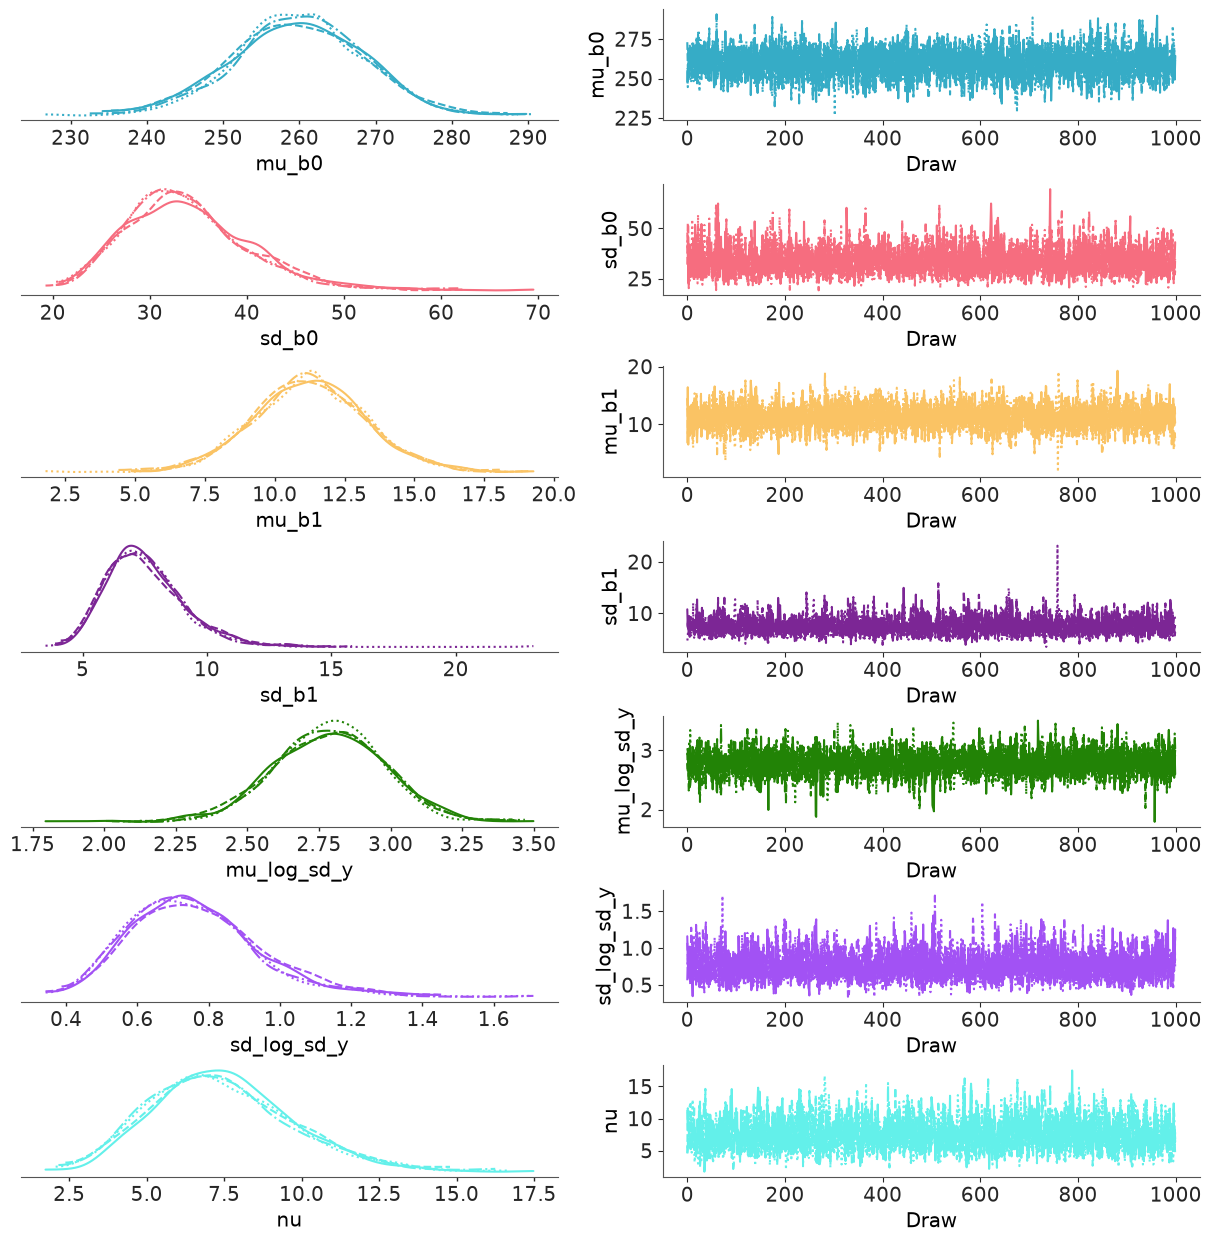

In [16]:
azp.plot_trace_dist(
    idata,
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "mu_log_sd_y", "sd_log_sd_y", "nu"],
);

### 3.4 Do the population-level parameters meet the diagnostic criteria?

Use the criteria established in Notebook 1: no divergences, R-hat close to 1, adequate bulk and tail ESS, and well-mixed traces.

Yes. There are no divergences, every population-level R-hat is 1.00, the bulk and tail ESS values are all above 1,600, and the traces show well-mixed chains, including those of `nu` and the residual-scale hyperparameters. With the smaller steps, the centered parameterization samples this model reliably.

### 3.5 Screen all participants, then inspect a representative subset.

In [17]:
participant_diagnostics = azs.summary(
    idata,
    var_names=["b0", "b1", "log_sd_y"],
    kind="diagnostics",
    round_to=2,
)

display(pd.DataFrame(
    {
        "value": [
            participant_diagnostics["r_hat"].max(),
            participant_diagnostics["ess_bulk"].min(),
            participant_diagnostics["ess_tail"].min(),
        ]
    },
    index=["largest R-hat", "smallest bulk ESS", "smallest tail ESS"],
))

diagnostic_participants = [
    participants[0],
    participants[len(participants) // 2],
    participants[-1],
]
diagnostic_coords = {"participant": diagnostic_participants}

azs.summary(
    idata,
    var_names=["b0", "b1", "log_sd_y"],
    coords=diagnostic_coords,
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

,value
largest R-hat,1.00
smallest bulk ESS,1937.51
smallest tail ESS,1722.33


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0[308],284.55,21.19,249.82,319.32,3405.63,3135.83,1.0,0.36,0.30
b0[337],304.99,10.36,287.77,320.95,2138.93,2053.48,1.0,0.23,0.21
b0[372],281.46,10.22,264.53,297.57,2298.66,2559.12,1.0,0.21,0.18
b1[308],18.39,5.06,10.57,26.76,3243.79,2709.18,1.0,0.09,0.07
b1[337],22.21,2.36,18.46,25.93,2288.57,2201.37,1.0,0.05,0.05
b1[372],11.56,2.32,7.82,15.26,2470.38,2662.26,1.0,0.05,0.04
log_sd_y[308],3.87,0.24,3.49,4.28,4202.28,2951.09,1.0,0.00,0.00
log_sd_y[337],2.60,0.35,2.02,3.15,3200.71,2567.22,1.0,0.01,0.01
log_sd_y[372],2.58,0.32,2.09,3.12,3091.93,2670.58,1.0,0.01,0.01


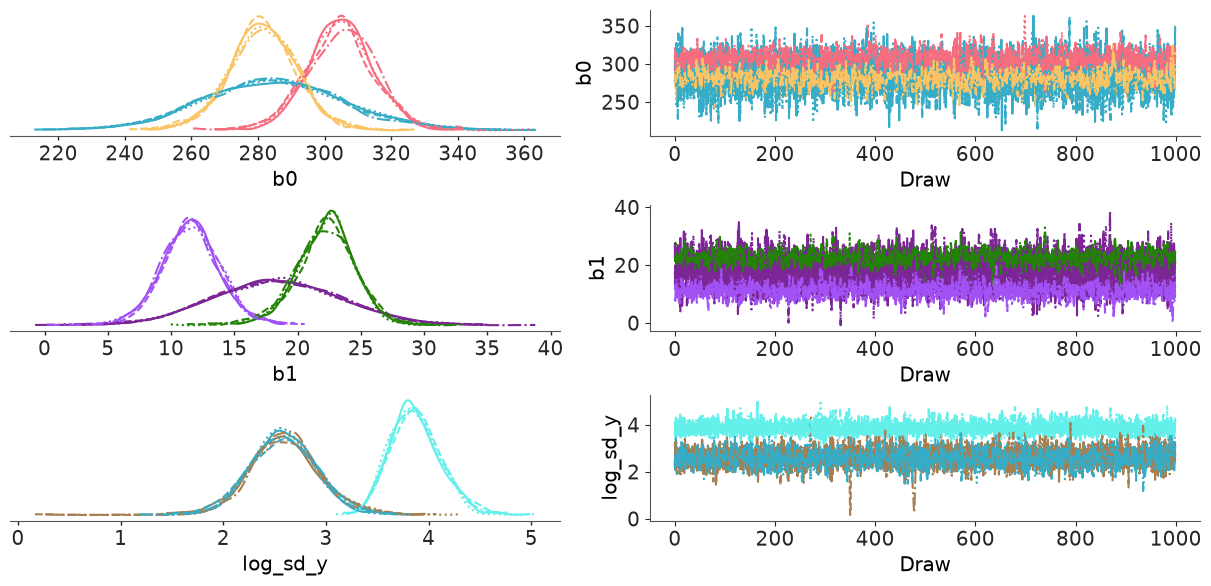

In [18]:
azp.plot_trace_dist(
    idata,
    var_names=["b0", "b1", "log_sd_y"],
    coords=diagnostic_coords,
);

### 3.6 Do the participant-level parameters meet the same criteria?

Yes. The all-participant screen, which includes the 18 log Gaussian standard deviations, shows a largest R-hat of 1.00 and smallest bulk and tail ESS values above 1,700, and the traces of `b0`, `b1`, and `log_sd_y` for participants 308, 337, and 372 mix well.

## 4. Examine the fitted ex-Gaussian components

### 4.1 Plot the posterior distribution of the population-average daily effect.

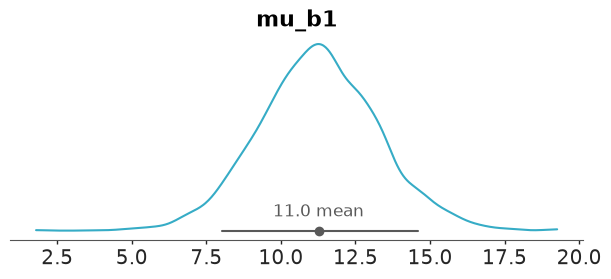

In [19]:
azp.plot_dist(
    idata,
    var_names=["mu_b1"],
    ci_prob=0.90,
    ci_kind="hdi",
    point_estimate="mean",
);

### 4.2 What range of population-average daily effects is credible?

Read the 90% HDI from your plot, and compare it with Notebook 5's estimate. In what units is it, and why?

The 90% HDI for `mu_b1` is approximately **8.0–14.6 ms/day**, essentially Notebook 5's interval. It is in milliseconds per day, as in Notebook 5, rather than the percentage change per day of Notebooks 6–8, because the mean structure is additive again (Question 1.6). Because the tail does not change with days, it is also the population-average daily change in expected reaction time (Question 1.8). Changing the likelihood and letting the residual scale vary by participant has not changed this conclusion.

### 4.3 Plot the posterior distribution of the tail mean `nu`.

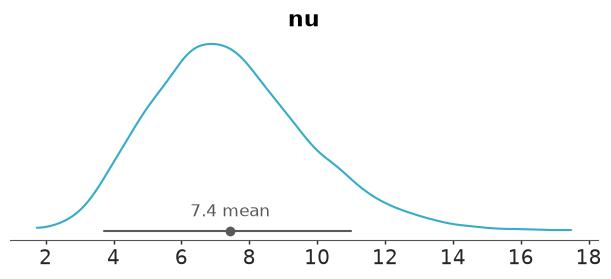

In [20]:
azp.plot_dist(
    idata,
    var_names=["nu"],
    ci_prob=0.90,
    ci_kind="hdi",
    point_estimate="mean",
);

### 4.4 How long is the fitted tail, and how far did the data move it from its prior?

Compare your plot with the prior for `nu` in Question 2.3.

The 90% HDI for `nu` is approximately **3.7–11 ms**, with a mean of about 7.4 ms: far shorter than the prior expected. The prior's median was 50 ms and its 90% HDI about 9–130 ms, so the posterior lies almost entirely in the lower tail of the prior; the data moved this parameter a long way.

The data mainly establish the upper end: the tail is at most about a dozen milliseconds. They cannot distinguish a tail of a few milliseconds from no tail at all, because as $\nu$ shrinks the ex-Gaussian approaches a Gaussian (Question 1.2), which fits almost equally well. The lower end of the interval, near 4 ms, is where the lower tail of the prior stops the posterior.

The short tail also explains the summary's `mu_b0`, about 260 ms, roughly 8 ms below Notebook 5's estimate of about 268 ms: `mu_b0` is now the location of the Gaussian part, and adding `nu` recovers the typical baseline expected reaction time (Question 1.8).

### 4.5 What does such a short tail mean for the shape of the reaction-time distribution?

A typical participant's Gaussian standard deviation is about $e^{2.8} \approx 16$ ms (summary in Question 3.3). Which curve in Question 1.2 does a typical participant's fitted distribution resemble? Why might the tail be so much shorter than we expected?

Nearly symmetric. With a tail mean of about 7 ms and a Gaussian standard deviation of about 16 ms, a typical participant's distribution resembles the $\nu = 5$ ms curve of Question 1.2, with only a slight right skew: once each participant's own trajectory and variability are accounted for, their day-to-day scatter is close to symmetric. Only for the steadiest participants, whose Gaussian standard deviations are a few milliseconds, is the tail a substantial part of their scatter (Question 3.2).

Part of the reason is what each observation is: a participant's average reaction time over a whole test session, not a single response. Single responses often have long right tails, from occasional lapses of attention, but averaging many of them removes most of that skew. A tail of tens of milliseconds, plausible for single responses, is too long for these averages.

### 4.6 Plot each participant's Gaussian standard deviation.

Use `azp.plot_forest` for `sd_y`, with 50% and 90% HDIs.

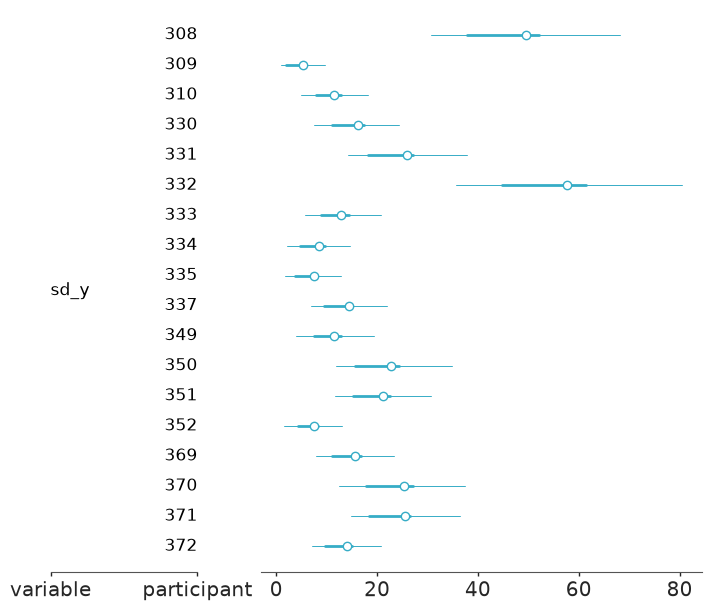

In [21]:
azp.plot_forest(
    idata,
    var_names=["sd_y"],
    combined=True,
    ci_probs=(0.50, 0.90),
    ci_kind="hdi",
    figure_kwargs={"figsize": (7, 6)},
);

### 4.7 How much do participants differ in day-to-day variability?

Base the answer on the participant intervals and on the posterior for `sd_log_sd_y` in the summary of Question 3.3, and express the difference between the steadiest and the most variable participants in milliseconds.

Substantially. The steadiest participant, 309, has a Gaussian standard deviation of about 5 ms (90% HDI roughly 1–10 ms), and 335 and 352 about 7.5 ms, while the most variable, 308 and 332, have about 49 and 58 ms (90% HDIs roughly 31–68 and 36–80 ms). The 90% HDI for `sd_log_sd_y`, about 0.47–1.03, is centered near the upper end of the prior's (0–0.8): as in Notebook 8, participants differ in variability more than the prior expected.

The Gaussian standard deviations differ roughly tenfold, partly because the shared tail also contributes to every participant's scatter. Because the two parts are independent, the total standard deviation of an ex-Gaussian is $\sqrt{sd_y^2 + \nu^2}$: about 10 ms for participant 309 and about 58 ms for participant 332, a six-fold difference in total day-to-day variability.

## 5. Predictive consequences

### 5.1 Plot each participant's posterior expected reaction time.

Use `plot_participants` with the variable that gives the expected reaction time in milliseconds.

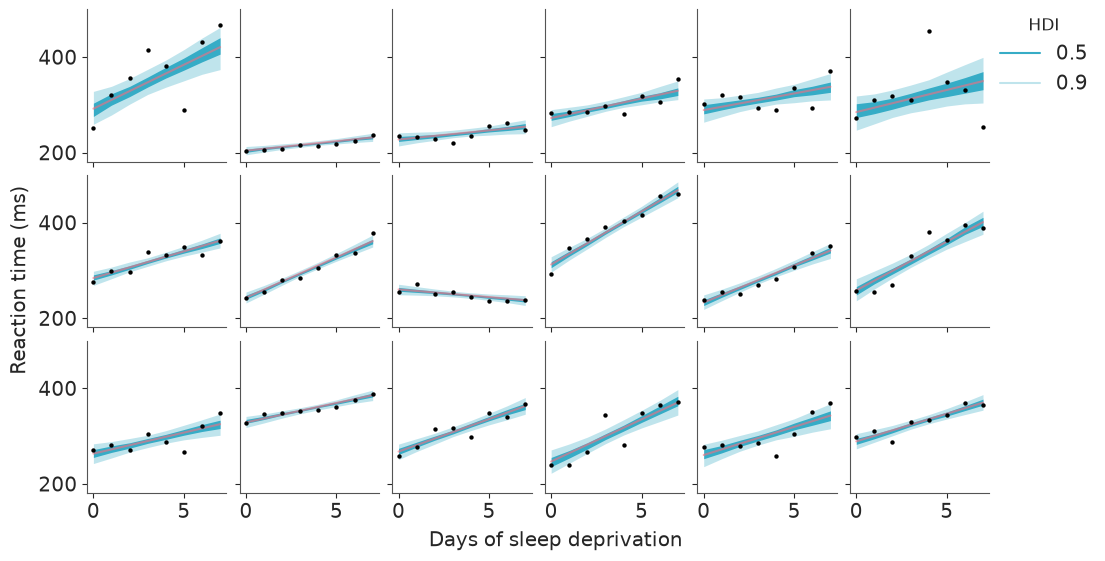

In [22]:
plot_participants(idata, "posterior", "mean_rt")
plt.show()

### 5.2 What uncertainty do these bands represent, and how would a plot of `mu_y` differ?

They show uncertainty about each participant's expected reaction time `mean_rt` on each day, not the day-to-day variation of individual reaction times. A plot of `mu_y` would show the same trajectories shifted down by $\nu$, about 7 ms (Question 1.4), with bands of almost the same width. With so short a tail, the location of the Gaussian part and the expected reaction time nearly coincide.

### 5.3 Generate and plot posterior predictive reaction times.

Generate replicated values of `y` from the fitted model, add them to `idata`, and compare them with the observations using `plot_participants`.

Sampling: [y]


Output()

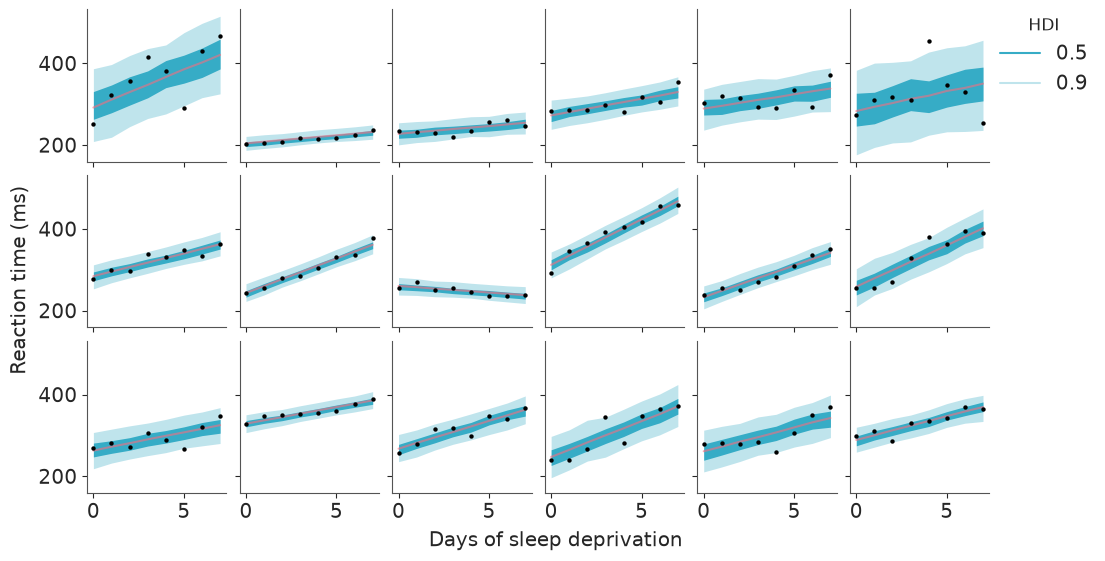

In [23]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

plot_participants(idata, "posterior_predictive", "y")
plt.show()

### 5.4 What is added when we move from `mean_rt` to posterior predictive `y`?

How do the widths of a participant's bands change across the week, and how does that differ from Notebook 8's lognormal model?

Residual day-to-day variation: each participant's Gaussian scatter, with their own `sd_y`, plus the short shared tail. The bands are wide for variable participants such as 308 and 332, whose 90% bands are about 170–220 ms wide, and narrow for steady ones such as 309, about 35 ms.

Because the Gaussian part is additive, each participant's bands keep roughly the same width in milliseconds throughout the week, even for participants whose reaction times rise steeply. In Notebook 8's lognormal model the variation was proportional, so the bands widened as reaction times rose: participant 308's 90% band, for example, widened from about 150 ms at baseline to about 220 ms on day 7. With a tail of only about 7 ms, the bands here are also nearly symmetric around the mean line.

### 5.5 Does the model reproduce the participant-level data?

Apply the posterior predictive criteria from Notebook 1: participants' overall levels, changes across days, and residual variation, emphasizing discrepancies that persist across a participant's observations. Compare with Notebook 5's check, in which all participants shared one residual standard deviation.

Yes. Each participant's level and rate of change are reproduced, as in Notebook 5, and each participant's bands now match their own day-to-day scatter. In Notebook 5 every participant's 90% band was roughly 90–100 ms wide: too wide for steady participants such as 309, and too narrow for the jumpy observations of 308 and 332. Here 309's observations spread across a narrow band, and those of 308 and 332 mostly fall inside much wider ones.

Only isolated observations fall outside or at the edge of the 90% bands, most clearly participant 308's fast reaction time on day 5 and participant 332's slow one on day 4. They are single days, not a pattern that persists within a participant. And although the likelihood allows negative reaction times, the fitted model essentially never produces one.

### 5.6 What would indicate adequate fit in an ECDF check?

The participant panels check conditional trajectories. Pooling all observations asks a different question: does the model reproduce the overall distribution of reaction times, including its right tail?

As in Notebooks 5–8, the observed ECDF should be broadly consistent with the posterior-predictive ECDFs across the whole distribution, without a persistent systematic displacement, particularly in the tails.

### 5.7 Plot the observed and posterior-predictive ECDFs.

Use `azp.plot_ppc_dist` with `kind="ecdf"`.

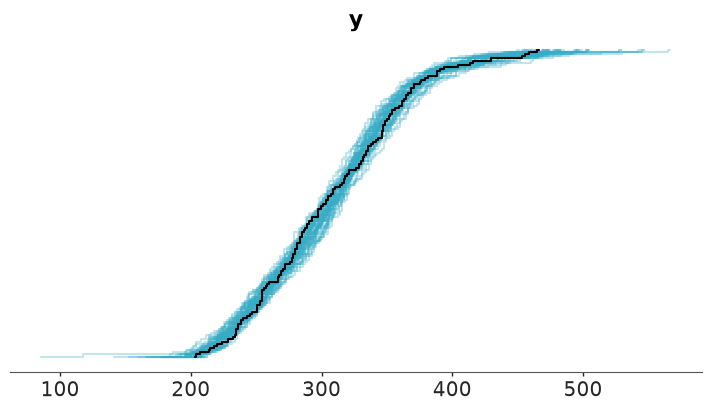

In [24]:
azp.plot_ppc_dist(
    idata,
    var_names=["y"],
    kind="ecdf",
    figure_kwargs={"figsize": (7, 4)},
);

### 5.8 Does the model reproduce the overall distribution, including its right tail?

The fitted tail is short (Question 4.4). Where does the right skew of the pooled reaction times come from in this model?

Broadly, yes. The observed ECDF lies within the spread of the posterior-predictive ECDFs across the whole distribution, with no persistent displacement in either tail.

The pooled right skew is reproduced even though each participant's scatter is nearly symmetric. It comes mainly from the mean structure: some participants are slower than others, and some slow down much more steeply over the week, so the pooled reaction times stretch out to the right. As in Notebooks 5–8, this pooled check cannot tell the model apart from the earlier hierarchical ones; their differences show in the participant-level checks.

## 6. Summary

### 6.1 What has this notebook shown?

Summarize what the ex-Gaussian model showed about the likelihood, the priors, sampling, the fitted components, and the predictive checks.

- **Likelihood.** An ex-Gaussian likelihood represents right skew through the shape of the distribution: a Gaussian part plus an independent exponential tail with mean $\nu$, so the expected reaction time is $\mu_y + \nu$. Its location is an ordinary millisecond-scale quantity, so the mean structure is Notebook 5's again, with `b1` in ms/day; only the positive parameters, the participants' Gaussian standard deviations and the shared tail mean, need a log link. Unlike the lognormal, the ex-Gaussian allows negative reaction times.
- **Priors.** Priors chosen in milliseconds and translated to the log scale gave prior predictions centered on plausible reaction times, unlike the log-scale priors of Notebooks 6–8, which centered baseline reaction times near 150 ms. As in Notebook 5, the broad mean-structure priors let the 90% bands reach below zero late in the week, and the upper tail of the between-participant prior occasionally produces an extreme participant, whose Gaussian part makes the mean line swing in both directions.
- **Sampling.** For steady participants, the data cannot rule out a very small Gaussian standard deviation; the distribution's left edge then becomes nearly vertical, and the posterior develops sharp edges. The centered parameterization sampled cleanly with `target_accept=0.99`.
- **Fitted components.** The population-average effect of sleep deprivation, about 8–14.6 ms/day, is essentially Notebook 5's. Participants' Gaussian standard deviations range from about 5 to 58 ms, more heterogeneous than the prior expected. The tail is short, at most about a dozen milliseconds and far below the prior's 50 ms: around each participant's trajectory, these session-average reaction times are nearly symmetric.
- **Predictive checks.** Each participant's predictive bands match their own day-to-day scatter and, because the variation is additive, keep a roughly constant width across the week. Replicated reaction times are essentially never negative, and the pooled ECDF, including its right tail, is broadly consistent with the data.